# TokenReceiv – Sprint 4 Final

## Plataforma Inteligente para Análise de Risco de Recebíveis

Este notebook apresenta a versão final do MVP TokenReceiv, desenvolvido para apoiar gestores de FIDCs na análise de risco, liquidez e comportamento financeiro de empresas a partir dos dados disponibilizados no desafio FIAP + Núclea.

In [ ]:
import pandas as pd
df =pd.read_csv("base_auxiliar_fiap.csv")
df.head()

,id_cnpj,cd_cnae_prin,uf,sacado_indice_liquidez_1m,cedente_indice_liquidez_1m,score_materialidade_evolucao,media_atraso_dias,indicador_liquidez_quantitativo_3m,share_vl_inad_pag_bol_6_a_15d,score_quantidade_v2,score_materialidade_v2
0,c137becbf8aeb57d1cb29eafa0506837ae986c18e10ba4...,4645101.0,PE,0.448191,0.677486,776.0,129.786932,0.92,0.03242,979.0,989.0
1,b1bb807c40ce30f95cc5259ad2eec9b9b9296e5b65a7fa...,1052000.0,CE,0.768871,NaN,220.0,90.203666,0.77,0.13992,938.0,989.0
2,4733136b86db508a2c0dcdfd849bbdd1452f30d4cb3ca0...,4781400.0,MS,0.798947,NaN,572.0,165.500000,0.96,0.00000,947.0,988.0
3,982036e318d814e915ae8c0d187cb125a6e8c5fa4b20f5...,4693100.0,PB,0.330366,0.751691,431.0,138.000000,0.87,0.34612,28.0,881.0
4,d63a468b6d43dee9a4c5aa7f8e9dab9a4b5584b5505a00...,2539001.0,SP,0.526669,NaN,173.0,84.619048,0.39,0.15071,74.0,949.0


In [ ]:
def calcular_score (linha):
     score = (
         (linha["score_materialidade_v2"] * 0.4) +
         (linha["score_quantidade_v2"] * 0.3) +
         (linha["sacado_indice_liquidez_1m"]  * 0.2) -
         (linha["media_atraso_dias"] * 1.0)
     )
     return score

df["score_final"] = df.apply(calcular_score, axis=1)

df.head()



,id_cnpj,cd_cnae_prin,uf,sacado_indice_liquidez_1m,cedente_indice_liquidez_1m,score_materialidade_evolucao,media_atraso_dias,indicador_liquidez_quantitativo_3m,share_vl_inad_pag_bol_6_a_15d,score_quantidade_v2,score_materialidade_v2,score_final
0,c137becbf8aeb57d1cb29eafa0506837ae986c18e10ba4...,4645101.0,PE,0.448191,0.677486,776.0,129.786932,0.92,0.03242,979.0,989.0,559.602706
1,b1bb807c40ce30f95cc5259ad2eec9b9b9296e5b65a7fa...,1052000.0,CE,0.768871,NaN,220.0,90.203666,0.77,0.13992,938.0,989.0,586.950108
2,4733136b86db508a2c0dcdfd849bbdd1452f30d4cb3ca0...,4781400.0,MS,0.798947,NaN,572.0,165.500000,0.96,0.00000,947.0,988.0,513.959789
3,982036e318d814e915ae8c0d187cb125a6e8c5fa4b20f5...,4693100.0,PB,0.330366,0.751691,431.0,138.000000,0.87,0.34612,28.0,881.0,222.866073
4,d63a468b6d43dee9a4c5aa7f8e9dab9a4b5584b5505a00...,2539001.0,SP,0.526669,NaN,173.0,84.619048,0.39,0.15071,74.0,949.0,317.286286


In [ ]:
df.columns

Index(['id_cnpj', 'cd_cnae_prin', 'uf', 'sacado_indice_liquidez_1m',
       'cedente_indice_liquidez_1m', 'score_materialidade_evolucao',
       'media_atraso_dias', 'indicador_liquidez_quantitativo_3m',
       'share_vl_inad_pag_bol_6_a_15d', 'score_quantidade_v2',
       'score_materialidade_v2', 'score_final'],
      dtype='object')

In [ ]:
df.to_csv("dados_com_score.csv", index=False)

In [ ]:
df["score_final"].describe()

,score_final
count,4589.000000
mean,462.522503
std,105.368387
min,-213.490000
25%,435.210474
50%,474.778738
75%,519.807564
max,691.200000


In [ ]:
df.sort_values(by="score_final" ,ascending=False).head(10)

,id_cnpj,cd_cnae_prin,uf,sacado_indice_liquidez_1m,cedente_indice_liquidez_1m,score_materialidade_evolucao,media_atraso_dias,indicador_liquidez_quantitativo_3m,share_vl_inad_pag_bol_6_a_15d,score_quantidade_v2,score_materialidade_v2,score_final
590,5cb302da75138a453fe69b9042a7b0dcac34343d565a96...,9521500.0,SC,1.000000,1.000000,956.0,0.0,0.99,0.0,986.0,988.0,691.200000
3341,8bc57b211466f683269e2b3573421496f106b8264c003a...,4713002.0,GO,1.000000,NaN,964.0,0.0,0.98,0.0,983.0,989.0,690.700000
3009,0a2e2592f5b3e483c808c8853dee750719c9f5cd82cde2...,4781400.0,MA,1.000000,NaN,966.0,0.0,0.98,0.0,983.0,988.0,690.300000
2414,f7707daa9f0cc2425803777c6f1d5e4ea9f1baa605c28f...,4771701.0,PR,0.998682,NaN,950.0,0.0,0.99,0.0,983.0,988.0,690.299736
217,2990f941e6c4ba5bf929cb96c6c5d2bad46510e912c3e6...,4752100.0,RJ,0.949281,0.883181,918.0,0.0,0.99,0.0,983.0,988.0,690.289856
3615,a4cf03ad8c0c46f85461a031d75b16b79624509333f73b...,4771701.0,PR,0.986215,NaN,950.0,0.0,0.98,0.0,981.0,989.0,690.097243
902,7510f8cfa8622b15b5dd78f0f880908140dc17443d1100...,4686902.0,ES,0.829696,1.000000,938.0,0.0,0.85,0.0,980.0,989.0,689.765939
974,d0d90a09b17f3caecd3c49ce30f2346337a59ef619ba3e...,4781400.0,PR,1.000000,NaN,911.0,0.0,0.98,0.0,981.0,988.0,689.700000
3795,d4bc85b904b70a8aa1434a33b2a3ef96eaa3af97bb4307...,4761003.0,MG,0.804433,1.000000,964.0,0.0,0.98,0.0,981.0,988.0,689.660887
2379,b4f6e93bcfdac6a517def30890db3a7071ee72186ee4df...,4744001.0,SC,0.986336,0.929618,964.0,0.0,0.97,0.0,980.0,988.0,689.397267


In [ ]:
df.sort_values(by="score_final",ascending=True).head(10)

,id_cnpj,cd_cnae_prin,uf,sacado_indice_liquidez_1m,cedente_indice_liquidez_1m,score_materialidade_evolucao,media_atraso_dias,indicador_liquidez_quantitativo_3m,share_vl_inad_pag_bol_6_a_15d,score_quantidade_v2,score_materialidade_v2,score_final
4327,39433ae72281095ade716a00b304f2563726aca445d8f1...,9602501.0,PE,0.050000,NaN,73.0,275.000000,0.08,0.00000,49.0,117.0,-213.490000
1396,1c1a94db7977750dec90c945ef1c2ca14e548afa038392...,4691500.0,SP,0.050000,NaN,38.0,191.250000,0.05,0.15746,25.0,56.0,-161.340000
1962,b156ee1de91b2c6cd3a9e9fccd3cfe59e6fe5c97ddb7de...,4635499.0,RJ,0.050000,NaN,32.0,206.222222,0.20,0.00000,37.0,144.0,-137.512222
432,c1ae6e7b1cf797c4e89d5f1187177617d65e37a3702f34...,3321000.0,RJ,0.050000,NaN,53.0,131.465839,0.05,0.09092,46.0,42.0,-100.855839
4514,94bc6a4ae186f2bba72de5f17f009c3fcda9f3a2524d42...,4781400.0,MA,0.228213,NaN,578.0,237.111111,1.00,0.10183,59.0,353.0,-78.165468
2038,b1e04e845536ca494dd2a3ede20b95cc6fb7915cefebb9...,810004.0,ES,0.050000,NaN,55.0,93.097561,0.16,0.04499,41.0,67.0,-53.987561
856,db72e7b8f0292d4d7aa455219c6c4e34ad1855e43b59b8...,4649499.0,PA,0.197486,NaN,152.0,168.885714,0.53,0.44751,28.0,353.0,-19.246217
1334,c23bebe8d2c948bf43ac4b64835fcc3f9b5f363856d4c2...,6470101.0,NaN,0.050000,0.209422,288.0,93.200000,0.53,0.00000,60.0,143.0,-17.990000
2482,af3f2fc7ad9fd8cfc12e314a094893327ec3e8b8ceec6f...,4399102.0,SP,0.050000,NaN,38.0,64.250000,0.05,0.22256,40.0,99.0,-12.640000
4282,750896a13962ef8b6b7538d599b84490475d8281408a60...,4782201.0,GO,0.067570,NaN,125.0,24.210526,0.26,0.28917,42.0,43.0,5.602988


In [ ]:
import pandas as pd

dados={
    'empresa':['A','B','C','D'],
    'atraso_dias':[5,30,10,0],
    'liquidez':[1.2,0.8,1.0,1.5],

}

df = pd.DataFrame(dados)

df.head()


,empresa,atraso_dias,liquidez
0,A,5,1.2
1,B,30,0.8
2,C,10,1.0
3,D,0,1.5


In [ ]:
import pandas as pd
df =pd.read_csv('base_auxiliar_fiap.csv')

df.head()

,id_cnpj,cd_cnae_prin,uf,sacado_indice_liquidez_1m,cedente_indice_liquidez_1m,score_materialidade_evolucao,media_atraso_dias,indicador_liquidez_quantitativo_3m,share_vl_inad_pag_bol_6_a_15d,score_quantidade_v2,score_materialidade_v2
0,c137becbf8aeb57d1cb29eafa0506837ae986c18e10ba4...,4645101.0,PE,0.448191,0.677486,776.0,129.786932,0.92,0.03242,979.0,989.0
1,b1bb807c40ce30f95cc5259ad2eec9b9b9296e5b65a7fa...,1052000.0,CE,0.768871,NaN,220.0,90.203666,0.77,0.13992,938.0,989.0
2,4733136b86db508a2c0dcdfd849bbdd1452f30d4cb3ca0...,4781400.0,MS,0.798947,NaN,572.0,165.500000,0.96,0.00000,947.0,988.0
3,982036e318d814e915ae8c0d187cb125a6e8c5fa4b20f5...,4693100.0,PB,0.330366,0.751691,431.0,138.000000,0.87,0.34612,28.0,881.0
4,d63a468b6d43dee9a4c5aa7f8e9dab9a4b5584b5505a00...,2539001.0,SP,0.526669,NaN,173.0,84.619048,0.39,0.15071,74.0,949.0


In [ ]:
df[['sacado_indice_liquidez_1m', 'cedente_indice_liquidez_1m']].head()

,sacado_indice_liquidez_1m,cedente_indice_liquidez_1m
0,0.448191,0.677486
1,0.768871,NaN
2,0.798947,NaN
3,0.330366,0.751691
4,0.526669,NaN


In [ ]:
def classificar_risco(liquidez):
    if liquidez < 0.5:
        return 'Alto risco'
    elif liquidez < 1:
        return 'Médio risco'
    else:
        return 'Baixo risco'

df['risco'] = df['sacado_indice_liquidez_1m'].apply(classificar_risco)

df[['sacado_indice_liquidez_1m', 'risco']].head()


,sacado_indice_liquidez_1m,risco
0,0.448191,Alto risco
1,0.768871,Médio risco
2,0.798947,Médio risco
3,0.330366,Alto risco
4,0.526669,Médio risco


In [ ]:
df['risco'].value_counts()

,count
risco,
Médio risco,3692
Alto risco,737
Baixo risco,183


<Axes: title={'center': 'Distribuição de Risco'}, xlabel='risco'>

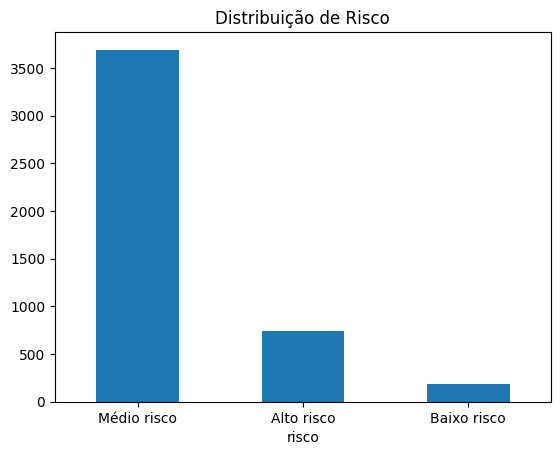

In [ ]:
df['risco'].value_counts().plot(kind='bar', title='Distribuição de Risco', rot=0)

## Dashboard Executivo do TokenReceiv

In [ ]:
# KPIs EXECUTIVOS

total_empresas = len(df)

media_score = df["score_final"].mean()

maior_score = df["score_final"].max()

menor_score = df["score_final"].min()

alto_risco = (df["risco"] == "Alto risco").sum()

medio_risco = (df["risco"] == "Médio risco").sum()

baixo_risco = (df["risco"] == "Baixo risco").sum()

print("========== DASHBOARD EXECUTIVO TOKENRECEIV ==========")

print(f"Total de empresas analisadas: {total_empresas}")

print(f"Média geral do score: {media_score:.2f}")

print(f"Maior score encontrado: {maior_score:.2f}")

print(f"Menor score encontrado: {menor_score:.2f}")

print(f"Empresas em Alto Risco: {alto_risco}")

print(f"Empresas em Médio Risco: {medio_risco}")

print(f"Empresas em Baixo Risco: {baixo_risco}")

KeyError: 'score_final'

In [ ]:
import matplotlib.pyplot as plt

distribuicao = df["risco"].value_counts()

plt.figure(figsize=(8,5))
distribuicao.plot(kind="bar")
plt.title("Distribuição das Empresas por Nível de Risco")
plt.xlabel("Classificação de Risco")
plt.ylabel("Quantidade de Empresas")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for i, valor in enumerate(distribuicao):
    plt.text(i, valor + 30, str(valor), ha="center")

plt.show()

In [ ]:
top_risco = df.sort_values(by="score_final").head(10)

top_risco[[
    "id_cnpj",
    "uf",
    "score_final",
    "media_atraso_dias",
    "risco"
]]

In [ ]:
print("========== INSIGHTS AUTOMÁTICOS ==========")

if medio_risco > alto_risco:
    print("A maior parte das empresas analisadas apresenta MÉDIO RISCO.")

if alto_risco > baixo_risco:
    print("O número de empresas em ALTO RISCO é significativamente maior que empresas em baixo risco.")

if media_score > 400:
    print("A média geral do score indica comportamento financeiro moderadamente estável.")

if menor_score < 0:
    print("Foram identificadas empresas com score negativo, indicando alto potencial de inadimplência.")

print("Empresas com maiores atrasos apresentaram os menores scores de risco.")

# Conclusão Final

O projeto TokenReceiv demonstrou a viabilidade de utilização de análise de dados para identificação de risco financeiro em empresas com base em indicadores de liquidez, atraso médio e materialidade.

A solução desenvolvida permitiu:

- calcular scores financeiros automatizados;
- classificar empresas por nível de risco;
- gerar dashboards executivos;
- identificar empresas críticas;
- produzir insights automáticos para apoio à tomada de decisão.

Os resultados obtidos demonstram que técnicas de análise de dados podem auxiliar gestores financeiros e FIDCs na redução de riscos e na priorização de análises de crédito.

Como evolução futura, o projeto poderá incorporar:

- Machine Learning;
- modelos preditivos;
- dashboards interativos em Power BI;
- integração com APIs financeiras;
- análise em tempo real.

O MVP desenvolvido atende aos objetivos propostos no desafio FIAP + Núclea, entregando uma solução funcional, analítica e escalável.